# 空间转录组数据整合方法教程
此脚本中考虑的输入数据是初始过滤后的全基因表达，没有筛选高可变异基因。常规整合要进行筛选  
`sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=3000)`

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")
import sys
import time
import subprocess
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import torch
import gc
import multiprocessing as mp 
import psutil
from datetime import datetime
from scipy.sparse import issparse
from PIL import Image
import shutil
import warnings
warnings.filterwarnings("ignore")

def release_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    time.sleep(0.5)

/home/xiaost/anaconda3/envs/py39/lib/python3.9/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


## 0. Data
导入示例数据，10x Visium 平台鼠脑组织，两张切片，左右拼接。  
https://www.10xgenomics.com/datasets/mouse-brain-serial-section-1-sagittal-anterior-1-standard-1-1-0  
https://www.10xgenomics.com/datasets/mouse-brain-serial-section-1-sagittal-posterior-1-standard-1-1-0  

这里直接读取了预处理好后的数据，预处理代码 https://github.com/xiaoshutong273/STADIM/blob/main/src/stadim/preprocess.py

In [2]:
## 已经合并了两张片子，并存储了原始计数 .layers['X_raw']
adata = ad.read_h5ad('/data2/xiaost/SODA/Data_Compare/Multi/MB1_pre.h5ad')
print(adata)

AnnData object with n_obs × n_vars = 6050 × 18330
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'size_factor'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable'
    uns: 'log1p', 'spatial', 'top_hvgs'
    obsm: 'S_scale', 'X_hvg_scale', 'X_pca', 'cell_names', 'spatial'
    layers: 'X_log', 'X_norm', 'X_raw'


In [3]:
adata.obs

,in_tissue,array_row,array_col,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,size_factor
MBSS1SA_AAACAAGTATCTCCCA-1,1,50,102,MBSS1SA,4461,8.403352,13990.0,9.546169,0.701869
MBSS1SA_AAACACCAATAACTGC-1,1,59,19,MBSS1SA,8117,9.001839,39788.0,10.591346,1.996137
MBSS1SA_AAACAGAGCGACTCCT-1,1,14,94,MBSS1SA,6521,8.782936,29151.0,10.280279,1.462486
MBSS1SA_AAACAGCTTTCAGAAG-1,1,43,9,MBSS1SA,8187,9.010425,42330.0,10.653275,2.123667
MBSS1SA_AAACAGGGTCTATATT-1,1,47,13,MBSS1SA,8085,8.997889,35695.0,10.482794,1.790794
...,...,...,...,...,...,...,...,...,...
MBSS1SP_TTGTTCAGTGTGCTAC-1,1,24,64,MBSS1SP,4518,8.416046,14765.0,9.600082,0.740750
MBSS1SP_TTGTTGTGTGTCAAGA-1,1,31,77,MBSS1SP,6081,8.713089,19269.0,9.866304,0.966713
MBSS1SP_TTGTTTCACATCCAGG-1,1,58,42,MBSS1SP,6842,8.830982,30805.0,10.335464,1.545466
MBSS1SP_TTGTTTCATTAGTCTA-1,1,60,30,MBSS1SP,4997,8.516793,17349.0,9.761348,0.870388


In [4]:
adata.var

,gene_ids,feature_types,genome,n_cells,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,highly_variable
Xkr4,ENSMUSG00000051951,Gene Expression,mm10,129,129,0.021983,0.021745,97.867769,133.0,4.897840,False
Gm19938,ENSMUSG00000102331,Gene Expression,mm10,142,142,0.024793,0.024491,97.652893,150.0,5.017280,False
Sox17,ENSMUSG00000025902,Gene Expression,mm10,854,854,0.163306,0.151266,85.884298,988.0,6.896694,False
Mrpl15,ENSMUSG00000033845,Gene Expression,mm10,3394,3394,1.033719,0.709866,43.900826,6254.0,8.741137,False
Lypla1,ENSMUSG00000025903,Gene Expression,mm10,2414,2414,0.581488,0.458366,60.099174,3518.0,8.165932,False
...,...,...,...,...,...,...,...,...,...,...,...
Spry3,ENSMUSG00000061654,Gene Expression,mm10,935,935,0.190909,0.174717,84.545455,1155.0,7.052721,False
Tmlhe,ENSMUSG00000079834,Gene Expression,mm10,297,297,0.050744,0.049498,95.090909,307.0,5.730100,False
4933409K07Rik,ENSMUSG00000095552,Gene Expression,mm10,17,17,0.002975,0.002971,99.719008,18.0,2.944439,False
CAAA01147332.1,ENSMUSG00000095742,Gene Expression,mm10,85,85,0.014050,0.013952,98.595041,85.0,4.454347,False


In [5]:
adata.uns

{'log1p': {},
 'spatial': {'MBSS1SA': {'images': {'hires': array([[[0.7176471 , 0.7372549 , 0.7294118 ],
            [0.7176471 , 0.7372549 , 0.7294118 ],
            [0.7176471 , 0.73333335, 0.7254902 ],
            ...,
            [0.7254902 , 0.74509805, 0.73333335],
            [0.7254902 , 0.74509805, 0.73333335],
            [0.7254902 , 0.74509805, 0.73333335]],
    
           [[0.7176471 , 0.7372549 , 0.7294118 ],
            [0.7176471 , 0.73333335, 0.7254902 ],
            [0.7176471 , 0.73333335, 0.7254902 ],
            ...,
            [0.7254902 , 0.74509805, 0.73333335],
            [0.7254902 , 0.7411765 , 0.73333335],
            [0.7254902 , 0.7411765 , 0.73333335]],
    
           [[0.7176471 , 0.73333335, 0.7254902 ],
            [0.7176471 , 0.7372549 , 0.7294118 ],
            [0.7176471 , 0.73333335, 0.7294118 ],
            ...,
            [0.7254902 , 0.7411765 , 0.73333335],
            [0.72156864, 0.7411765 , 0.73333335],
            [0.7254902 , 0.74509

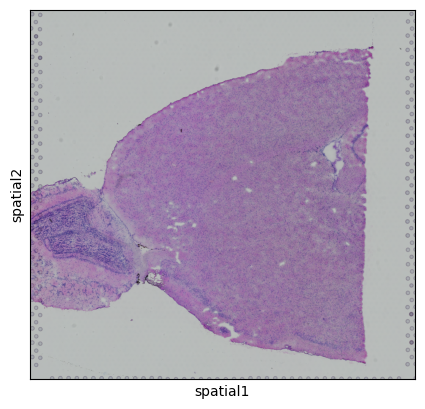

In [6]:
sc.pl.spatial(adata,library_id='MBSS1SA')

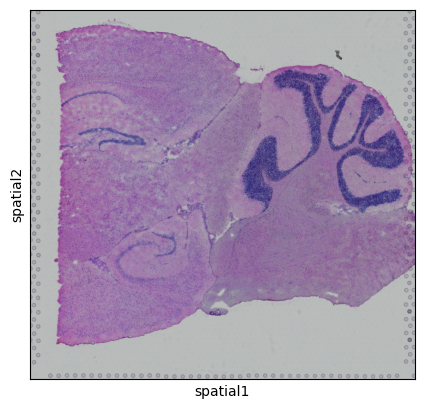

In [7]:
sc.pl.spatial(adata,library_id='MBSS1SP')

## 1. Scanpy 没有整合能力，用作对照

In [8]:
def run_scanpy(adata: ad.AnnData):
    success = True
    error_msg = None
    print("Running Scanpy...")
    try:
        adata_tmp = adata.copy()
        adata.obsm['Scanpy'] = adata_tmp.obsm['X_pca'].copy()    
    except Exception as e:
        success = False
        error_msg = str(e)
        print(f"Exception in Scanpy: {e}")
    finally:
        release_gpu()
    return adata, success, error_msg

In [9]:
adata, success, error_msg = run_scanpy(adata)
print(adata)
print(success)
print(error_msg)

Running Scanpy...
AnnData object with n_obs × n_vars = 6050 × 18330
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'size_factor'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable'
    uns: 'log1p', 'spatial', 'top_hvgs'
    obsm: 'S_scale', 'X_hvg_scale', 'X_pca', 'cell_names', 'spatial', 'Scanpy'
    layers: 'X_log', 'X_norm', 'X_raw'
True
None


## 2. Harmony 单细胞整合方法

In [10]:
def run_harmony(adata: ad.AnnData, basis: str="X_pca", harmony_obsm: str='Harmony'):
    success = True
    error_msg = None
    print(f"Running Harmony on {basis}...")
    try:
        adata_tmp = adata.copy()        
        sc.external.pp.harmony_integrate(adata_tmp, key="sample", basis=basis, adjusted_basis="X_pca_harmony")
        adata.obsm[harmony_obsm] = adata_tmp.obsm["X_pca_harmony"].copy()
    except Exception as e:
        success = False
        error_msg = str(e)
        print(f"Exception in Harmony: {e}")
    finally:
        release_gpu()
    return adata, success, error_msg

In [11]:
adata, success, error_msg = run_harmony(adata)
print(adata)
print(success)
print(error_msg)

Running Harmony on X_pca...


2026-06-17 00:34:24,307 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-06-17 00:34:25,656 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-06-17 00:34:25,680 - harmonypy - INFO - Iteration 1 of 10
2026-06-17 00:34:26,691 - harmonypy - INFO - Iteration 2 of 10
2026-06-17 00:34:27,710 - harmonypy - INFO - Iteration 3 of 10
2026-06-17 00:34:28,757 - harmonypy - INFO - Iteration 4 of 10
2026-06-17 00:34:29,795 - harmonypy - INFO - Iteration 5 of 10
2026-06-17 00:34:30,833 - harmonypy - INFO - Iteration 6 of 10
2026-06-17 00:34:31,734 - harmonypy - INFO - Iteration 7 of 10
2026-06-17 00:34:32,496 - harmonypy - INFO - Iteration 8 of 10
2026-06-17 00:34:33,565 - harmonypy - INFO - Iteration 9 of 10
2026-06-17 00:34:34,599 - harmonypy - INFO - Iteration 10 of 10
2026-06-17 00:34:35,276 - harmonypy - INFO - Stopped before convergence


AnnData object with n_obs × n_vars = 6050 × 18330
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'size_factor'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable'
    uns: 'log1p', 'spatial', 'top_hvgs'
    obsm: 'S_scale', 'X_hvg_scale', 'X_pca', 'cell_names', 'spatial', 'Scanpy', 'Harmony'
    layers: 'X_log', 'X_norm', 'X_raw'
True
None


## 3. STAGATE
该方法适用于垂直方向连续切片

In [12]:
def run_stagate_adjacent(adata: ad.AnnData, device: str = 'cuda:2'):
    success = True
    error_msg = None
    print("Running STAGATE_adjacent...")
    try:
        import STAGATE_pyG as STAGATE
        
        adata_tmp = adata.copy()
        adata_tmp.var = adata_tmp.var.drop(columns=['highly_variable'], errors='ignore') 
        adata_tmp.X = adata_tmp.layers['X_raw'].copy()
        sc.pp.normalize_total(adata_tmp, target_sum=1e4)
        sc.pp.log1p(adata_tmp)
        adata.layers['STAGATE_1e4_log'] = adata_tmp.X.copy()

        section_ids = sorted(adata_tmp.obs['sample'].unique()) 
        print(f"STAGATE_adjacent: use sample order {section_ids}")
        
        STAGATE.Cal_Spatial_Net_3D(adata_tmp, rad_cutoff_2D=150, rad_cutoff_Zaxis=150, 
                                   key_section='sample', section_order=section_ids, verbose=True)
        trained = STAGATE.train_STAGATE(adata_tmp, save_reconstrction=True, device=device)
        adata.obsm['STAGATE'] = trained.obsm['STAGATE'].copy()
        adata.layers['STAGATE_log'] = trained.layers['STAGATE_ReX'].copy()
        
        if hasattr(trained, "uns") and "Spatial_Net" in trained.uns:
            adata.uns["Spatial_Net"] = trained.uns["Spatial_Net"]
        if hasattr(trained, "obsp"):
            for k in trained.obsp.keys():
                adata.obsp[k] = trained.obsp[k]
    except Exception as e:
        success = False
        error_msg = str(e)
        print(f"Exception in STAGATE: {e}")
    finally:
        release_gpu()
    return adata, success, error_msg

In [13]:
adata, success, error_msg = run_stagate_adjacent(adata)
print(adata)
print(success)
print(error_msg)

Running STAGATE_adjacent...
STAGATE_adjacent: use sample order ['MBSS1SA', 'MBSS1SP']
Radius used for 2D SNN: 150
Radius used for SNN between sections: 150
------Calculating 2D SNN of section  MBSS1SA
This graph contains 15656 edges, 2695 cells.
5.8093 neighbors per cell on average.
------Calculating 2D SNN of section  MBSS1SP
This graph contains 19598 edges, 3355 cells.
5.8414 neighbors per cell on average.
------Calculating SNN between adjacent section MBSS1SA and MBSS1SP.
This graph contains 18354 edges, 6050 cells.
3.0337 neighbors per cell on average.
3D SNN contains 53608 edges, 6050 cells.
8.8608 neighbors per cell on average.
Size of Input:  (6050, 18330)


100%|██████████| 1000/1000 [00:46<00:00, 21.57it/s]


AnnData object with n_obs × n_vars = 6050 × 18330
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'size_factor'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable'
    uns: 'log1p', 'spatial', 'top_hvgs', 'Spatial_Net'
    obsm: 'S_scale', 'X_hvg_scale', 'X_pca', 'cell_names', 'spatial', 'Scanpy', 'Harmony', 'STAGATE'
    layers: 'X_log', 'X_norm', 'X_raw', 'STAGATE_1e4_log', 'STAGATE_log'
True
None


## 4. STAligner

In [14]:
def run_staligner(adata: ad.AnnData, rad_cutoff: float = 150, device: str = 'cuda:2'):
    success = True
    error_msg = None
    print(f"Running STAligner (rad_cutoff={rad_cutoff})...")
    try:
        import STAligner
        import scipy.linalg
        from scipy.sparse import csr_matrix
        
        adata_tmp = adata.copy()
        if 'cell_names' in adata_tmp.obsm:
            del adata_tmp.obsm['cell_names'] 
        adata_tmp.var = adata_tmp.var.drop(columns=['highly_variable'], errors='ignore') 
        adata_tmp.X = adata_tmp.layers['X_raw'].copy()
        adata_tmp.raw = adata_tmp.copy()

        Batch_list = []
        adj_list = []
        section_ids = sorted(adata_tmp.obs['sample'].unique())
        cell_order = []

        for section_id in section_ids:
            section_adata = adata_tmp[adata_tmp.obs['sample'] == section_id].copy()
            section_adata.X = csr_matrix(section_adata.X)
            STAligner.Cal_Spatial_Net(section_adata, rad_cutoff=rad_cutoff) 
            sc.pp.highly_variable_genes(section_adata, flavor="seurat_v3", n_top_genes=5000)
            sc.pp.normalize_total(section_adata, target_sum=1e4)
            sc.pp.log1p(section_adata)
            section_adata = section_adata[:, section_adata.var['highly_variable']]
            adj_list.append(section_adata.uns['adj'])
            Batch_list.append(section_adata)
            cell_order.extend(section_adata.obs_names.tolist())

        adata_concat = ad.concat(Batch_list, label="slice_name", keys=section_ids)
        adata_concat.obs["batch_name"] = adata_concat.obs["slice_name"].astype('category')
        
        adj_concat = np.asarray(adj_list[0].todense())
        for batch_id in range(1, len(section_ids)):
            adj_concat = scipy.linalg.block_diag(adj_concat, np.asarray(adj_list[batch_id].todense()))
        adata_concat.uns['edgeList'] = np.nonzero(adj_concat)
        
        adata_concat = STAligner.train_STAligner(adata_concat, verbose=True, knn_neigh=100, device=device)
        
        aligner_feat_df = pd.DataFrame(adata_concat.obsm['STAligner'], index=cell_order)
        adata.obsm['STAligner'] = aligner_feat_df.loc[adata.obs_names].values

    except Exception as e:
        success = False
        error_msg = str(e)
        print(f"Exception in STAligner: {e}")
    finally:
        release_gpu()
    return adata, success, error_msg

In [15]:
adata, success, error_msg = run_staligner(adata)
print(adata)
print(success)
print(error_msg)

Running STAligner (rad_cutoff=150)...
------Calculating spatial graph...
The graph contains 15656 edges, 2695 cells.
5.8093 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 19598 edges, 3355 cells.
5.8414 neighbors per cell on average.
STAligner(
  (conv1): GATConv(3109, 512, heads=1)
  (conv2): GATConv(512, 30, heads=1)
  (conv3): GATConv(30, 512, heads=1)
  (conv4): GATConv(512, 3109, heads=1)
)
Pretrain with STAGATE...


100%|██████████| 500/500 [00:05<00:00, 95.76it/s]


Train with STAligner...


  0%|          | 0/500 [00:00<?, ?it/s]

Update spot triplets at epoch 500


...

Update spot triplets at epoch 800


 80%|███████▉  | 399/500 [00:10<00:01, 70.62it/s]

Update spot triplets at epoch 900


100%|██████████| 500/500 [00:13<00:00, 37.12it/s]


AnnData object with n_obs × n_vars = 6050 × 18330
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'size_factor'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable'
    uns: 'log1p', 'spatial', 'top_hvgs', 'Spatial_Net'
    obsm: 'S_scale', 'X_hvg_scale', 'X_pca', 'cell_names', 'spatial', 'Scanpy', 'Harmony', 'STAGATE', 'STAligner'
    layers: 'X_log', 'X_norm', 'X_raw', 'STAGATE_1e4_log', 'STAGATE_log'
True
None


## 5. SEDR
这个全基因结果不可靠，还是用了HVG

In [16]:
def run_sedr_hvg(adata: ad.AnnData, nei: int = 12, device: str = 'cuda:2'):
    success = True
    error_msg = None
    print(f"Running SEDR_hvg (nei={nei})...")
    try:
        import SEDR
        adata_tmp = adata.copy()
        adata_tmp.X = adata_tmp.layers['X_raw'].copy()
        adata_tmp.layers['count'] = adata_tmp.X.toarray() if hasattr(adata_tmp.X, "toarray") else adata_tmp.X.copy()
        sc.pp.normalize_total(adata_tmp, target_sum=1e6)
        sc.pp.highly_variable_genes(adata_tmp, flavor="seurat_v3", layer='count', n_top_genes=2000)
        adata_tmp = adata_tmp[:, adata_tmp.var['highly_variable'] == True]
        hvg_genes = adata_tmp.var_names.tolist()
        sc.pp.scale(adata_tmp)
        adata_tmp.layers['SEDR_scale'] = adata_tmp.X.copy()
        
        proj_list = sorted(adata_tmp.obs['sample'].unique())
        graph_dict = None
        cell_order = []
        
        for proj_name in proj_list:
            adata_proj = adata_tmp[adata_tmp.obs['sample'] == proj_name].copy()
            graph_dict_tmp = SEDR.graph_construction(adata_proj, nei) 
            
            if proj_name == proj_list[0]:
                graph_dict = graph_dict_tmp
            else:
                graph_dict = SEDR.combine_graph_dict(graph_dict, graph_dict_tmp)
            
            cell_order.extend(adata_proj.obs_names.tolist())
        
        adata_ordered = adata_tmp[cell_order].copy()
        adata.uns['SEDR_hvg_genes'] = hvg_genes

        ## denoising
        ddata = adata_ordered.copy()
        SEDR.fix_seed(2023)
        sedr_net = SEDR.Sedr(ddata.X, graph_dict, mode='imputation', device=device) 
        sedr_net.train_with_dec()
        sedr_feat, _, _, _ = sedr_net.process()
        de_feat = sedr_net.recon()

        sedr_feat_df = pd.DataFrame(sedr_feat, index=cell_order)
        de_feat_df = pd.DataFrame(de_feat, index=cell_order, columns=adata_ordered.var_names)

        sedr_rec_full = np.zeros(adata.shape, dtype=np.float32) 
        hvg_indices = [adata.var_names.get_loc(gene) for gene in hvg_genes]
        sedr_rec_full[:, hvg_indices] = de_feat_df.loc[adata.obs_names].values

        adata.obsm['SEDR_hvg_emb_im'] = sedr_feat_df.loc[adata.obs_names].values
        adata.layers['SEDR_hvg'] = sedr_rec_full

        ## integration
        edata = adata_ordered.copy()
        from sklearn.decomposition import PCA 
        edata.X = edata.layers['SEDR_scale'].copy()
        edata.obsm['X_pca'] = PCA(n_components=200, random_state=42).fit_transform(edata.X) #scale
        SEDR.fix_seed(2023)
        sedr_net = SEDR.Sedr(edata.obsm['X_pca'], graph_dict, mode='clustering', device=device) 
        sedr_net.train_without_dec()
        sedr_feat, _, _, _ = sedr_net.process()
        
        sedr_feat_df = pd.DataFrame(sedr_feat, index=cell_order)
        adata.obsm['SEDR_hvg_emb_clu'] = sedr_feat_df.loc[adata.obs_names].values

        adata, harmony_success, harmony_error = run_harmony(adata, 'SEDR_hvg_emb_clu', 'SEDR.Harmony')
        if not harmony_success:
            print(f"SEDR_hvg Harmony failed: {harmony_error}")
        
    except Exception as e:
        success = False
        error_msg = str(e)
        print(f"Exception in SEDR_hvg: {e}")
    finally:
        release_gpu()
    return adata, success, error_msg

In [17]:
adata, success, error_msg = run_sedr_hvg(adata)
print(adata)
print(success)
print(error_msg)

Running SEDR_hvg (nei=12)...


100%|██████████| 200/200 [00:08<00:00, 24.32it/s]


Running Harmony on SEDR_hvg_emb_clu...


2026-06-17 00:36:32,217 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-06-17 00:36:33,290 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-06-17 00:36:33,310 - harmonypy - INFO - Iteration 1 of 10
2026-06-17 00:36:34,215 - harmonypy - INFO - Iteration 2 of 10
2026-06-17 00:36:35,142 - harmonypy - INFO - Iteration 3 of 10
2026-06-17 00:36:36,064 - harmonypy - INFO - Iteration 4 of 10
2026-06-17 00:36:36,947 - harmonypy - INFO - Iteration 5 of 10
2026-06-17 00:36:37,839 - harmonypy - INFO - Iteration 6 of 10
2026-06-17 00:36:38,740 - harmonypy - INFO - Iteration 7 of 10
2026-06-17 00:36:39,608 - harmonypy - INFO - Iteration 8 of 10
2026-06-17 00:36:40,477 - harmonypy - INFO - Converged after 8 iterations


AnnData object with n_obs × n_vars = 6050 × 18330
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'size_factor'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable'
    uns: 'log1p', 'spatial', 'top_hvgs', 'Spatial_Net', 'SEDR_hvg_genes'
    obsm: 'S_scale', 'X_hvg_scale', 'X_pca', 'cell_names', 'spatial', 'Scanpy', 'Harmony', 'STAGATE', 'STAligner', 'SEDR_hvg_emb_im', 'SEDR_hvg_emb_clu', 'SEDR.Harmony'
    layers: 'X_log', 'X_norm', 'X_raw', 'STAGATE_1e4_log', 'STAGATE_log', 'SEDR_hvg'
True
None


## 6. GraphST

In [18]:
def run_graphst(adata: ad.AnnData, device: str = 'cuda:2'):
    success = True
    error_msg = None
    print("Running GraphST...")
    try:
        sys.path.append("/data2/xiaost/SODA/STDML/compare/GraphST-main")
        from GraphST import GraphST
        from sklearn.decomposition import PCA
        
        adata_tmp = adata.copy()
        adata_tmp.X = adata_tmp.layers['X_raw'].copy()
        samples = adata_tmp.obs['sample'].unique()
        
        # DLPFC 处理
        if any(s in ['151507', '151669', '151673'] for s in samples):
            all_centers = []
            for s in samples:
                mask = adata_tmp.obs['sample'] == s
                coords = adata_tmp.obsm['spatial'][mask]
                center = coords.mean(axis=0)
                all_centers.append(center)
            
            global_center = np.mean(all_centers, axis=0)
            new_spatial = adata_tmp.obsm['spatial'].copy()
            for s in samples:
                mask = adata_tmp.obs['sample'] == s
                coords = adata_tmp.obsm['spatial'][mask]
                sample_center = coords.mean(axis=0)
                new_spatial[mask] = coords - (sample_center - global_center) 
            
            adata_tmp.obsm['spatial'] = new_spatial
            adata.obsm['CCS'] = new_spatial 
        
        # MB 处理
        elif any(s in ['MBSS1SA', 'MBSS2SA'] for s in samples):
            sorted_samples = sorted(samples) 
            sample_coords = {}
            for s in sorted_samples:
                mask = adata_tmp.obs['sample'] == s
                coords = adata_tmp.obsm['spatial'][mask]
                sample_coords[s] = {
                    'coords': coords,
                    'min_x': coords[:, 0].min(),
                    'max_x': coords[:, 0].max(),
                    'center_y': coords[:, 1].mean()
                }
            
            left_sample = sorted_samples[0]
            right_sample = sorted_samples[1]
            left_width = sample_coords[left_sample]['max_x'] - sample_coords[left_sample]['min_x']
            gap = 1.0 
            
            new_spatial = adata_tmp.obsm['spatial'].copy()
            left_mask = adata_tmp.obs['sample'] == left_sample
            new_spatial[left_mask] = sample_coords[left_sample]['coords'] - [
                sample_coords[left_sample]['min_x'], 
                sample_coords[left_sample]['center_y']
            ]
            
            right_mask = adata_tmp.obs['sample'] == right_sample
            right_shift_x = left_width + gap 
            new_spatial[right_mask] = sample_coords[right_sample]['coords'] - [
                sample_coords[right_sample]['min_x'], 
                sample_coords[right_sample]['center_y'] 
            ] + [right_shift_x, 0] 
            
            adata_tmp.obsm['spatial'] = new_spatial
            adata.obsm['CCS'] = new_spatial 

        adata_tmp = sc.AnnData(
            X=adata.layers['X_raw'].copy(),
            obs=adata.obs[['in_tissue', 'array_row', 'array_col']].copy(),
            var=adata.var[['gene_ids', 'feature_types', 'genome']].copy(),
            obsm={'spatial': adata.obsm['CCS'].copy()},
            uns={'spatial': adata.uns['spatial'].copy()}
        )
        
        model = GraphST.GraphST(adata_tmp, device=device, random_seed=50)
        adata_tmp = model.train()
        adata.obsm['GraphST_2000'] = adata_tmp.obsm['emb'].copy()
        
        pca = PCA(n_components=20, random_state=42) 
        embedding = pca.fit_transform(adata.obsm['GraphST_2000'].copy())
        adata.obsm['GraphST'] = embedding
        
    except Exception as e:
        success = False
        error_msg = str(e)
        print(f"Exception in GraphST: {e}")
    finally:
        release_gpu()
    return adata, success, error_msg

In [19]:
adata, success, error_msg = run_graphst(adata)
print(adata)
print(success)
print(error_msg)

Running GraphST...
Begin to train ST data...


100%|██████████| 600/600 [00:19<00:00, 30.23it/s]


Optimization finished for ST data!
AnnData object with n_obs × n_vars = 6050 × 18330
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'size_factor'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable'
    uns: 'log1p', 'spatial', 'top_hvgs', 'Spatial_Net', 'SEDR_hvg_genes'
    obsm: 'S_scale', 'X_hvg_scale', 'X_pca', 'cell_names', 'spatial', 'Scanpy', 'Harmony', 'STAGATE', 'STAligner', 'SEDR_hvg_emb_im', 'SEDR_hvg_emb_clu', 'SEDR.Harmony', 'CCS', 'GraphST_2000', 'GraphST'
    layers: 'X_log', 'X_norm', 'X_raw', 'STAGATE_1e4_log', 'STAGATE_log', 'SEDR_hvg'
True
None


## 7. DeepST

In [20]:
def run_deepst(adata: ad.AnnData, output_dir: str, device: str = 'cuda:2'):
    success = True
    error_msg = None
    print("Running DeepST...")
    try:
        sys.path.append("/data2/xiaost/SODA/STDML/compare/DeepST-main")
        import deepstkit as dt
        adata_tmp = adata.copy()
        if 'cell_names' in adata_tmp.obsm:
            del adata_tmp.obsm['cell_names']
        adata_tmp.X = adata_tmp.layers['X_raw'].copy()

        dt.utils_func.seed_torch(seed=0)
        
        results_dir = os.path.join(output_dir, 'DeepST')
        os.makedirs(results_dir, exist_ok=True)
        integration_model = dt.main.run(save_path=results_dir, 
                                        task="Integration", pre_epochs=500, epochs=500, 
                                        use_gpu=True if 'cuda' in device else False)
        
        processed_data = []
        spatial_graphs = []
        cell_order = []
        sample_ids = sorted(adata_tmp.obs['sample'].unique())
        
        for sample_id in sample_ids:
            sample_adata = adata_tmp[adata_tmp.obs['sample'] == sample_id].copy()
            sample_adata = integration_model._get_augment(
                sample_adata, spatial_type="BallTree", use_morphological=False
            )
            graph = integration_model._get_graph(
                sample_adata.obsm["spatial"], distType="KDTree"
            )
            processed_data.append(sample_adata)
            spatial_graphs.append(graph)
            cell_order.extend(sample_adata.obs_names.tolist())
        
        combined_adata, combined_graph = integration_model._get_multiple_adata(
            adata_list=processed_data, data_name_list=sample_ids, graph_list=spatial_graphs
        )
        
        integrated_data = integration_model._data_process(combined_adata, pca_n_comps=200)
        
        embeddings = integration_model._fit(
            data=integrated_data,
            graph_dict=combined_graph,
            domains=combined_adata.obs['sample'].astype('category').cat.codes.values.astype(np.int64), 
            n_domains=len(sample_ids)
        )

        deepst_emb_df = pd.DataFrame(embeddings, index=cell_order)
        adata.obsm['DeepST'] = deepst_emb_df.loc[adata.obs_names].values
        print(f"DeepST embedding shape: {adata.obsm['DeepST'].shape}")

    except Exception as e:
        success = False
        error_msg = str(e)
        print(f"Exception in DeepST: {e}")
    finally:
        release_gpu()
    return adata, success, error_msg

In [22]:
adata, success, error_msg = run_deepst(adata,'/data2/xiaost/Trash')
print(adata)
print(success)
print(error_msg)

Running DeepST...
Spatial weights calculated. Average neighbors: 30.0
Gene expression weights calculated.
Final weight matrix calculated and stored in adata.obsm['weights_matrix_all']


Finding adjacent spots: 100%|██████████ [ time left: 00:00 ]


Step 1: Data augmentation completed
12.0000 neighbors per cell on average.
Step 2: Spatial graph computation completed
Spatial weights calculated. Average neighbors: 30.0
Gene expression weights calculated.
Final weight matrix calculated and stored in adata.obsm['weights_matrix_all']


Finding adjacent spots: 100%|██████████ [ time left: 00:00 ]


Step 1: Data augmentation completed
12.0000 neighbors per cell on average.
Step 2: Spatial graph computation completed
Running DeepST analysis...


Pretraining initial model: 100%|██████████ [ time left: 00:00 ]
Training final model: 100%|██████████ [ time left: 00:00 ]


Step 3: DeepST training completed
Memory usage: 16.02 GB
Total time: 0.71 minutes
Analysis completed successfully
DeepST embedding shape: (6050, 28)
AnnData object with n_obs × n_vars = 6050 × 18330
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'size_factor'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable'
    uns: 'log1p', 'spatial', 'top_hvgs', 'Spatial_Net', 'SEDR_hvg_genes'
    obsm: 'S_scale', 'X_hvg_scale', 'X_pca', 'cell_names', 'spatial', 'Scanpy', 'Harmony', 'STAGATE', 'STAligner', 'SEDR_hvg_emb_im', 'SEDR_hvg_emb_clu', 'SEDR.Harmony', 'CCS', 'GraphST_2000', 'GraphST', 'DeepST'
    layers: 'X_log', 'X_norm', 'X_raw', 'STAGATE_1e4_log', 'STAGATE_log', 'SEDR_hvg'
True
None


## 8. 处理图像拼接

In [23]:
import scanpy as sc
import numpy as np
from PIL import Image, ImageFilter

def stitch_images(merged_adata, source_paths_map):
    print("开始执行：单边定向裁剪拼接...")
    
    # 1. 基础检查与参数获取
    common_samples = set(merged_adata.obs['sample'].unique()).intersection(source_paths_map.keys())
    if not common_samples: raise ValueError("样本名称不匹配！")

    first_sample = list(common_samples)[0]
    first_adata = sc.read_h5ad(source_paths_map[first_sample])
    first_lib = list(first_adata.uns['spatial'].keys())[0]
    
    scale_factor = first_adata.uns['spatial'][first_lib]['scalefactors']['tissue_hires_scalef']
    spot_diameter = first_adata.uns['spatial'][first_lib]['scalefactors']['spot_diameter_fullres']
    
    sample_images = {}
    global_min_x, global_min_y = float('inf'), float('inf')

    # 定义分组 (在这里添加新的样本名)
    # SA组: 切除右侧 (保留左边)
    group_cut_right = ['MBSS1SA', 'MBSS2SA'] 
    # SP组: 切除左侧 (保留右边)
    group_cut_left  = ['MBSS1SP', 'MBSS2SP']
    
    # 2. 循环处理每个样本
    for s_name in common_samples:
        print(f"处理: {s_name}")
        path = source_paths_map[s_name]
        
        # 读取图像
        src_adata = sc.read_h5ad(path) if s_name != first_sample else first_adata
        img_arr = src_adata.uns['spatial'][list(src_adata.uns['spatial'].keys())[0]]['images']['hires']
        
        # 转 RGBA 并去白底 (可选，保留以防重叠遮挡)
        if img_arr.max() <= 1.0: img_arr = (img_arr * 255).astype(np.uint8)
        else: img_arr = img_arr.astype(np.uint8)
        img_pil = Image.fromarray(img_arr).convert("RGBA")
        
        # 简单去白底逻辑 (防止保留区域遮挡)
        gray = np.mean(np.array(img_pil.convert("RGB")), axis=2)
        mask = Image.fromarray(np.where(gray > 230, 0, 255).astype(np.uint8)).filter(ImageFilter.GaussianBlur(2))
        img_pil.putalpha(mask)

        # --- 核心：计算单边裁剪边界 ---
        mask_idx = merged_adata.obs['sample'] == s_name
        raw_coords = merged_adata[mask_idx].obsm['raw_spatial'] # (N, 2)
        
        # 获取点在像素坐标系下的极值
        p_min_x = np.min(raw_coords[:, 0]) * scale_factor
        p_max_x = np.max(raw_coords[:, 0]) * scale_factor
        
        # 默认裁剪框：全图保留 (0, 0, W, H)
        crop_left, crop_top, crop_right, crop_bottom = 0, 0, img_pil.width, img_pil.height
        
        # === 修改后的判断逻辑 ===
        if s_name in group_cut_right:
            # 如果是 SA 类样本：切右侧 (裁剪到最右边的点)
            crop_right = int(p_max_x) 
            print(f"  -> {s_name} (组:SA) 右侧裁剪至 x={crop_right}")
            
        elif s_name in group_cut_left:
            # 如果是 SP 类样本：切左侧 (裁剪到最左边的点)
            crop_left = int(p_min_x)
            print(f"  -> {s_name} (组:SP) 左侧裁剪至 x={crop_left}")
            
        # 执行裁剪
        cropped_img = img_pil.crop((crop_left, crop_top, crop_right, crop_bottom))
        
        # --- 计算粘贴位置 ---
        # 逻辑：粘贴坐标 = (当前spot坐标 - 原始spot坐标) + 裁剪图左上角在原图的偏移
        curr_coords = merged_adata[mask_idx].obsm['spatial']
        # 取第一个点计算平移向量 (Vector)
        vec_x = (curr_coords[0, 0] - raw_coords[0, 0]) * scale_factor
        vec_y = (curr_coords[0, 1] - raw_coords[0, 1]) * scale_factor
        
        # 裁剪图在画布上的位置 = (原始原点(0,0)的映射位置) + (裁剪造成的左/上偏移)
        # 原始原点映射位置 = 0 + Vector
        # 裁剪造成的偏移 = crop_left
        paste_x = vec_x + crop_left
        paste_y = vec_y + crop_top
        
        sample_images[s_name] = {'img': cropped_img, 'x': paste_x, 'y': paste_y}
        global_min_x = min(global_min_x, paste_x)
        global_min_y = min(global_min_y, paste_y)

    # 3. 计算画布与偏移
    padding = 200
    shift_x = -global_min_x + padding if global_min_x < 0 else padding
    shift_y = -global_min_y + padding if global_min_y < 0 else padding
    
    # 物理坐标平移量 (用于更新 adata)
    shift_physical_x = shift_x / scale_factor
    shift_physical_y = shift_y / scale_factor

    # 确定画布大小
    max_w, max_h = 0, 0
    for d in sample_images.values():
        d['final_x'] = int(d['x'] + shift_x)
        d['final_y'] = int(d['y'] + shift_y)
        max_w = max(max_w, d['final_x'] + d['img'].width)
        max_h = max(max_h, d['final_y'] + d['img'].height)
        
    print(f"最终画布尺寸: {max_w} x {max_h}")
    merged_img = Image.new('RGBA', (max_w, max_h), (255, 255, 255, 255))
    
    # 4. 粘贴与保存
    for d in sample_images.values():
        merged_img.paste(d['img'], (d['final_x'], d['final_y']), mask=d['img'])
        
    # 5. 更新 adata
    merged_adata.obsm['spatial'] = merged_adata.obsm['spatial'].astype(float)
    merged_adata.obsm['spatial'][:, 0] += shift_physical_x
    merged_adata.obsm['spatial'][:, 1] += shift_physical_y
    
    merged_adata.uns['spatial'] = {}
    merged_adata.uns['spatial']['merged_sample'] = {
        'images': { 'hires': np.array(merged_img.convert("RGB")) / 255.0 },
        'scalefactors': {
            'tissue_hires_scalef': scale_factor,
            'spot_diameter_fullres': spot_diameter
        }
    }
    return merged_adata


adata.obsm['raw_spatial'] = adata.obsm['spatial'].copy()
adata.obsm['spatial'] = adata.obsm['CCS'].copy()

mask = adata.obs['sample'] == 'MBSS1SA'
adata.obsm['spatial'][mask, 1] += 250
path_dict = {
    'MBSS1SA': '/data2/xiaost/SODA/Data/MB/MBSS1SA.h5ad',
    'MBSS1SP': '/data2/xiaost/SODA/Data/MB/MBSS1SP.h5ad' 
}
adata = stitch_images(adata, path_dict)
adata

开始执行：单边定向裁剪拼接...
处理: MBSS1SP
  -> MBSS1SP (组:SP) 左侧裁剪至 x=282
处理: MBSS1SA
  -> MBSS1SA (组:SA) 右侧裁剪至 x=1640
最终画布尺寸: 3558 x 2263


AnnData object with n_obs × n_vars = 6050 × 18330
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'size_factor'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable'
    uns: 'log1p', 'spatial', 'top_hvgs', 'Spatial_Net', 'SEDR_hvg_genes'
    obsm: 'S_scale', 'X_hvg_scale', 'X_pca', 'cell_names', 'spatial', 'Scanpy', 'Harmony', 'STAGATE', 'STAligner', 'SEDR_hvg_emb_im', 'SEDR_hvg_emb_clu', 'SEDR.Harmony', 'CCS', 'GraphST_2000', 'GraphST', 'DeepST', 'raw_spatial'
    layers: 'X_log', 'X_norm', 'X_raw', 'STAGATE_1e4_log', 'STAGATE_log', 'SEDR_hvg'

## 9. Louvain 聚类

In [26]:
import matplotlib.pyplot as plt
my_colors = [
  '#c49c94', '#1f77b4', '#bcbd22', "#BCD896", '#9edae5', '#c7c7c7', # 0-5
  '#c5b0d5', '#2ca02c', '#17becf', '#aec7e8', '#ff9896', '#ff7f0e', # 6-11
  '#98df8a', '#e377c2', '#d62728', '#f7b6d3', "#6BBE92", '#8c564b', # 12-17
  '#FCC616', "#9b2626", '#d6616b', '#9467bd', '#dbdb8d', "#E97F5A",# 18-23
  '#ffbb78', '#e7969c', '#ffff99', "#637939", '#a55194', '#e7969c', # 24-29
]

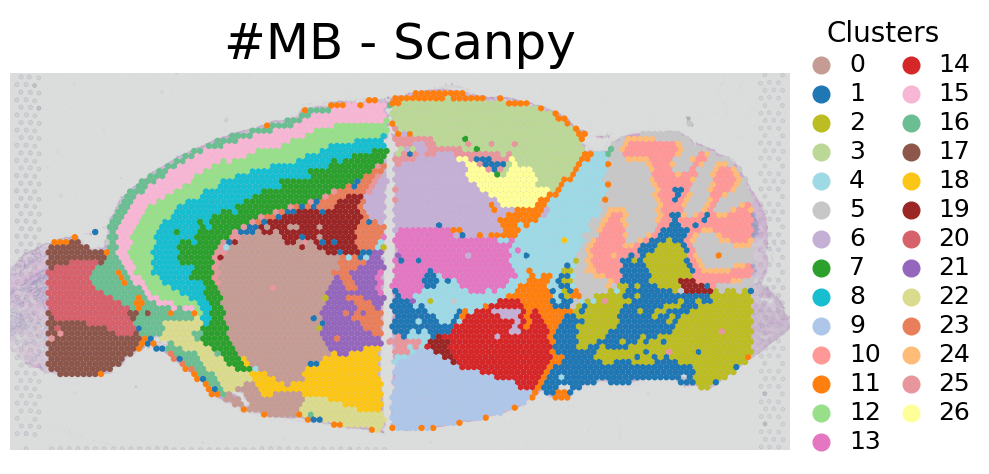

In [27]:
method = 'Scanpy'
cluster_key = f"{method}_clusters"
sc.pp.neighbors(adata, use_rep=method, key_added=method)
sc.tl.louvain(adata, neighbors_key=method, key_added=cluster_key, resolution=1.4)
n_clusters = len(adata.obs[cluster_key].unique())

# if n_clusters==nnn:
adata.uns[f"{cluster_key}_colors"] = my_colors[:n_clusters]

fig, ax = plt.subplots(figsize=(10, 8))
sc.pl.spatial(adata, color=cluster_key, spot_size=150, title=None, show=False, ax=ax, alpha_img=0.5)
ax.set_title(f"#MB - {method}", fontsize=36, pad=10)#fontweight='bold', 
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_aspect('equal') # 锁定纵横比
ax.axis('off')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="Clusters", title_fontsize=20, fontsize=18, handletextpad=0.1,#key和文字距离
          ncol=2, loc='upper left', bbox_to_anchor=(0.98, 1.2), labelspacing=0.2, columnspacing=0.2, markerscale=2, frameon=False)

plt.tight_layout()
# plt.savefig(os.path.join(FIGURES_DIR, f"a_{name}_{method}_spatial.pdf"), dpi=100, bbox_inches='tight', format='pdf', transparent=True)
plt.show()

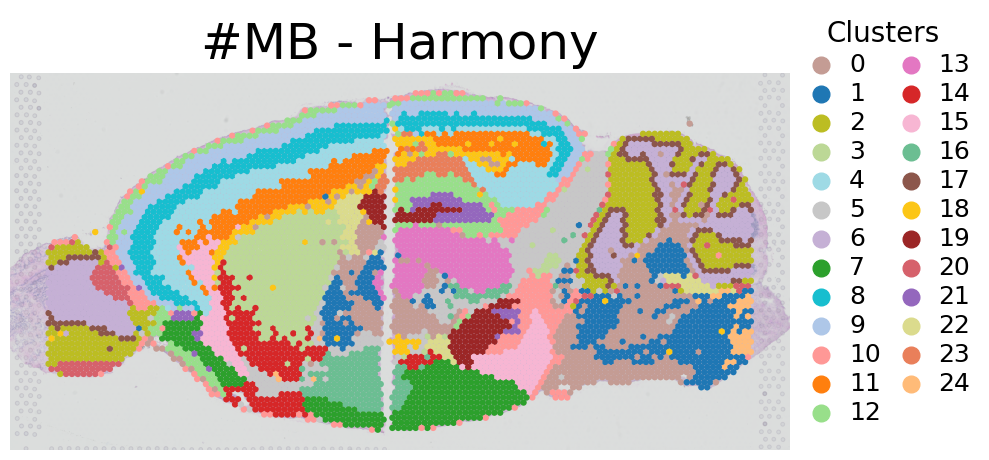

In [28]:
method = 'Harmony'
cluster_key = f"{method}_clusters"
sc.pp.neighbors(adata, use_rep=method, key_added=method)
sc.tl.louvain(adata, neighbors_key=method, key_added=cluster_key, resolution=1.6)
n_clusters = len(adata.obs[cluster_key].unique())

# if n_clusters==nnn:
adata.uns[f"{cluster_key}_colors"] = my_colors[:n_clusters]

fig, ax = plt.subplots(figsize=(10, 8))
sc.pl.spatial(adata, color=cluster_key, spot_size=150, title=None, show=False, ax=ax, alpha_img=0.5)
ax.set_title(f"#MB - {method}", fontsize=36, pad=10)#fontweight='bold', 
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_aspect('equal') # 锁定纵横比
ax.axis('off')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="Clusters", title_fontsize=20, fontsize=18, handletextpad=0.1,#key和文字距离
          ncol=2, loc='upper left', bbox_to_anchor=(0.98, 1.2), labelspacing=0.2, columnspacing=0.2, markerscale=2, frameon=False)

plt.tight_layout()
# plt.savefig(os.path.join(FIGURES_DIR, f"a_{name}_{method}_spatial.pdf"), dpi=100, bbox_inches='tight', format='pdf', transparent=True)
plt.show()

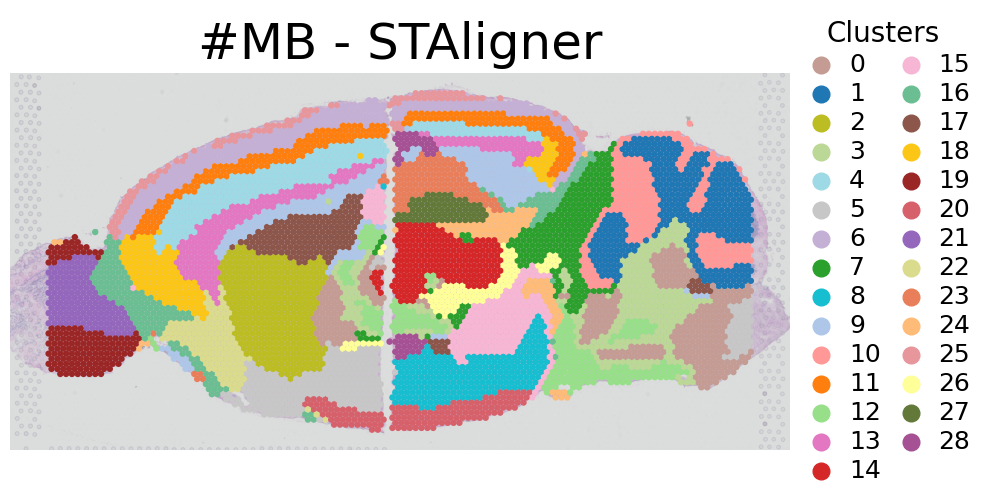

In [29]:
method = 'STAligner'
cluster_key = f"{method}_clusters"
sc.pp.neighbors(adata, use_rep=method, key_added=method)
sc.tl.louvain(adata, neighbors_key=method, key_added=cluster_key, resolution=1.3)
n_clusters = len(adata.obs[cluster_key].unique())

# if n_clusters==nnn:
adata.uns[f"{cluster_key}_colors"] = my_colors[:n_clusters]

fig, ax = plt.subplots(figsize=(10, 8))
sc.pl.spatial(adata, color=cluster_key, spot_size=150, title=None, show=False, ax=ax, alpha_img=0.5)
ax.set_title(f"#MB - {method}", fontsize=36, pad=10)#fontweight='bold', 
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_aspect('equal') # 锁定纵横比
ax.axis('off')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="Clusters", title_fontsize=20, fontsize=18, handletextpad=0.1,#key和文字距离
          ncol=2, loc='upper left', bbox_to_anchor=(0.98, 1.2), labelspacing=0.2, columnspacing=0.2, markerscale=2, frameon=False)

plt.tight_layout()
# plt.savefig(os.path.join(FIGURES_DIR, f"a_{name}_{method}_spatial.pdf"), dpi=100, bbox_inches='tight', format='pdf', transparent=True)
plt.show()

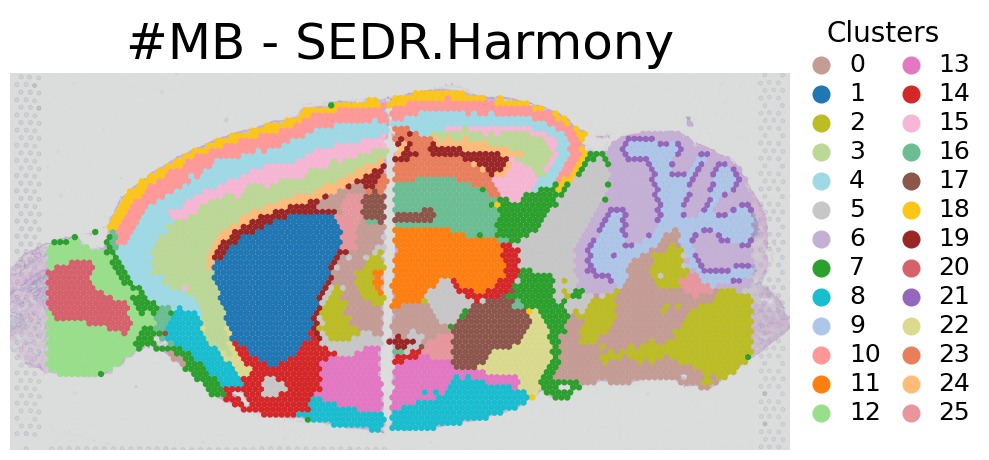

In [30]:
method = 'SEDR.Harmony'
cluster_key = f"{method}_clusters"
sc.pp.neighbors(adata, use_rep=method, key_added=method)
sc.tl.louvain(adata, neighbors_key=method, key_added=cluster_key, resolution=1.4)
n_clusters = len(adata.obs[cluster_key].unique())

# if n_clusters==nnn:
adata.uns[f"{cluster_key}_colors"] = my_colors[:n_clusters]

fig, ax = plt.subplots(figsize=(10, 8))
sc.pl.spatial(adata, color=cluster_key, spot_size=150, title=None, show=False, ax=ax, alpha_img=0.5)
ax.set_title(f"#MB - {method}", fontsize=36, pad=10)#fontweight='bold', 
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_aspect('equal') # 锁定纵横比
ax.axis('off')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="Clusters", title_fontsize=20, fontsize=18, handletextpad=0.1,#key和文字距离
          ncol=2, loc='upper left', bbox_to_anchor=(0.98, 1.2), labelspacing=0.2, columnspacing=0.2, markerscale=2, frameon=False)

plt.tight_layout()
# plt.savefig(os.path.join(FIGURES_DIR, f"a_{name}_{method}_spatial.pdf"), dpi=100, bbox_inches='tight', format='pdf', transparent=True)
plt.show()

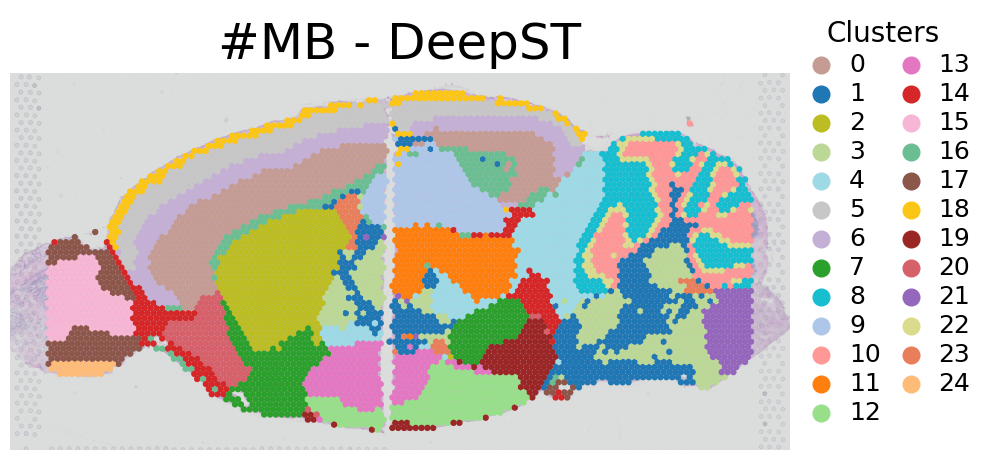

In [31]:
method = 'DeepST'
cluster_key = f"{method}_clusters"
sc.pp.neighbors(adata, use_rep=method, key_added=method)
sc.tl.louvain(adata, neighbors_key=method, key_added=cluster_key, resolution=1.4)
n_clusters = len(adata.obs[cluster_key].unique())

# if n_clusters==nnn:
adata.uns[f"{cluster_key}_colors"] = my_colors[:n_clusters]

fig, ax = plt.subplots(figsize=(10, 8))
sc.pl.spatial(adata, color=cluster_key, spot_size=150, title=None, show=False, ax=ax, alpha_img=0.5)
ax.set_title(f"#MB - {method}", fontsize=36, pad=10)#fontweight='bold', 
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_aspect('equal') # 锁定纵横比
ax.axis('off')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="Clusters", title_fontsize=20, fontsize=18, handletextpad=0.1,#key和文字距离
          ncol=2, loc='upper left', bbox_to_anchor=(0.98, 1.2), labelspacing=0.2, columnspacing=0.2, markerscale=2, frameon=False)

plt.tight_layout()
# plt.savefig(os.path.join(FIGURES_DIR, f"a_{name}_{method}_spatial.pdf"), dpi=100, bbox_inches='tight', format='pdf', transparent=True)
plt.show()

In [32]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import warnings
import tempfile
warnings.filterwarnings('ignore')

# 设置R环境变量
conda_r_home = "/home/xiaost/anaconda3/envs/py39/lib/R"
os.environ['R_HOME'] = conda_r_home
os.environ['LD_LIBRARY_PATH'] = f"{conda_r_home}/lib"
os.environ['PATH'] = f"{conda_r_home}/bin:{os.environ['PATH']}"

import rpy2.robjects as robjects

def mmclust_R(adata, n_clusters, modelNames='EEE', used_obsm='STAGATE_emb', random_seed=2023):
    """使用R的mclust进行聚类 - 通过临时文件传递数据"""
    np.random.seed(random_seed)
    
    try:
        # 加载mclust库
        robjects.r.library("mclust")
        
        # 获取数据
        data = adata.obsm[used_obsm].copy()
        data = np.asarray(data, dtype=np.float64)
        
        print(f"Data shape: {data.shape}")
        print(f"Clustering into {n_clusters} clusters")
        
        # 创建临时文件保存数据
        with tempfile.NamedTemporaryFile(mode='w', suffix='.csv', delete=False) as f:
            temp_file = f.name
            # 写入数据（不包含行列索引）
            np.savetxt(f, data, delimiter=',')
        
        try:
            # 在R中读取CSV并进行聚类
            robjects.r(f'''
                data <- read.csv('{temp_file}', header=FALSE)
                set.seed({random_seed})
                mclust_result <- Mclust(as.matrix(data), G={n_clusters}, modelNames='{modelNames}')
                cluster_labels <- mclust_result$classification
            ''')
            
            # 提取结果
            mclust_res = np.array(robjects.r['cluster_labels'])
            mclust_res = np.asarray(mclust_res).flatten().astype(int)
            
            print(f"Unique clusters: {np.unique(mclust_res)}")
            print(f"Cluster distribution: {np.bincount(mclust_res)}")
            
            # 保存结果
            adata.obs['mclust'] = pd.Categorical(mclust_res)
            
            return adata
            
        finally:
            # 删除临时文件
            if os.path.exists(temp_file):
                os.remove(temp_file)
        
    except Exception as e:
        print(f"Error in clustering: {e}")
        raise

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.



Data shape: (6050, 20)
Clustering into 26 clusters
fitting ...
  |======================================================================| 100%
Unique clusters: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26]
Cluster distribution: [  0 111  49 187 347 189 147 428 379 158 218 249 401 123 205 524 471 226
 330 186  90 193 314 196  97 103 129]


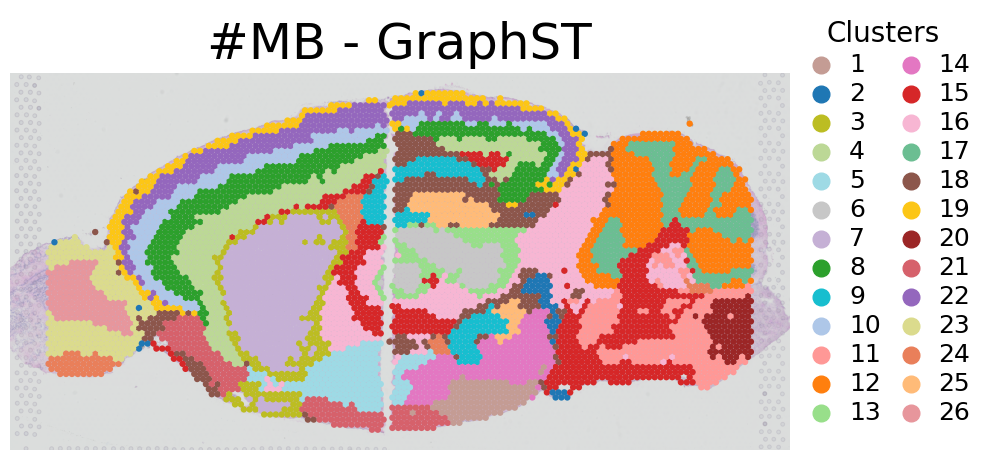

In [33]:
method = 'GraphST'
cluster_key = f"{method}_clusters"
adata = mmclust_R(adata, n_clusters=26, used_obsm='GraphST')
adata.obs[cluster_key] = adata.obs['mclust']
categories = adata.obs[cluster_key].cat.categories
n_cats = len(categories)
adata.uns[f"{cluster_key}_colors"] = my_colors[:n_cats]

fig, ax = plt.subplots(figsize=(10, 8))
sc.pl.spatial(adata, color=cluster_key, spot_size=150, title=None, show=False, ax=ax, alpha_img=0.5)
ax.set_title(f"#MB - {method}", fontsize=36, pad=10)#fontweight='bold', 
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_aspect('equal') # 锁定纵横比
ax.axis('off')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="Clusters", title_fontsize=20, fontsize=18, handletextpad=0.1,#key和文字距离
          ncol=2, loc='upper left', bbox_to_anchor=(0.98, 1.2), labelspacing=0.2, columnspacing=0.2, markerscale=2, frameon=False)

plt.tight_layout()
# plt.savefig(os.path.join(FIGURES_DIR, f"a_{name}_{method}_spatial.pdf"), dpi=100, bbox_inches='tight', format='pdf', transparent=True)
plt.show()